# Metody redukcji wymiaru

* 01.12.2025 Jadwiga Krząstek

Zagadnienia na dziś:
- PCA (w tym definicja objaśnianej wariancji)
- ICA
- Podejścia nieliniowe (MDS, UMAP, t-SNE, ...)

<h4> Zadanie1: Rozważ dane dotyczące nowotworu piersi.
    
    
- Podziel dane na zbiór treningowy i testowy
    
- Dokonaj standaryzacji, a nastepnie przeprowadź algorytm PCA (pamiętaj o: fit_transform na train i transform na test).
    
- Ile komponent należy zostawić aby opisać przynajmniej 90% zmienności tych danych?
    
- Zwizualizuj wyniki wykorzysując jedynie pierwsze dwie komponenty. Pokoloruj obserwacje wg kategorii. Czy kategorie są (przynajmniej częściowo) rozseparowane?
    
- Zbuduj model SVM i/lub Regresji logistycznej na: pełnym zbiorze danych, zredukowanych danych do 6 komponent oraz zredukowanych danych do 2 komponent. Dokonaj oceny tych modeli. Skomentuj otrzymane wyniki.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [1]:
from sklearn import datasets

bc = datasets.load_breast_cancer()

In [2]:
print("Labels: ", bc.target_names) #na jakie kategorie dane są podzielone

Labels:  ['malignant' 'benign']


In [3]:
print("Features: ", bc.feature_names) #jakie cechy były brane pod uwagę, łącznie 30

Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
X, y = bc.data, bc.target

#### **Część 1**: Analiza PCA

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca_full = PCA(n_components=None)
pca_full.fit(X_train_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

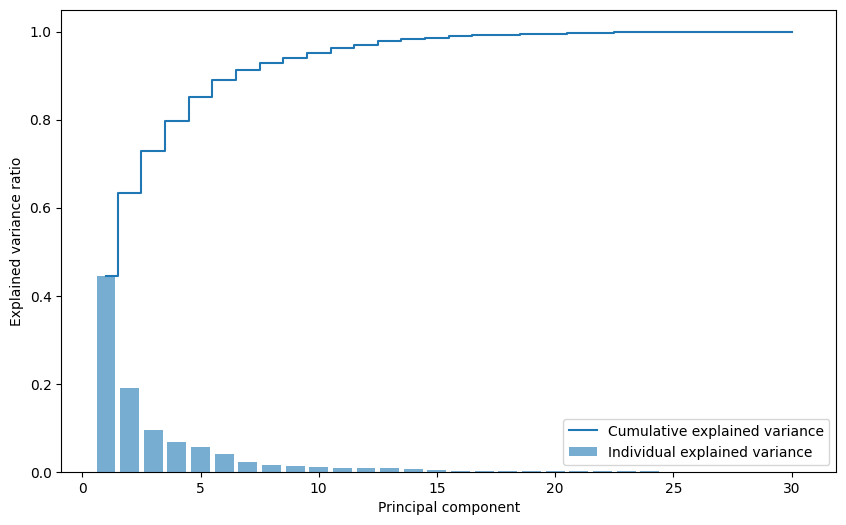

In [10]:
plt.figure(figsize=(10,6))
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, label='Individual explained variance')
plt.step(range(1, len(var_exp)+1), var_exp_cum, where='mid', label='Cumulative explained variance')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.legend(loc='best')
plt.show()


**Odpowiedź:** należy zostawić ok. 5-6 komponent.

In [8]:
pca2 = PCA(n_components=2)

X_train_pca = pca2.fit_transform(X_train_scaled)
X_test_pca  = pca2.transform(X_test_scaled)

print("Shape after PCA:", X_train_pca.shape)


Shape after PCA: (455, 2)


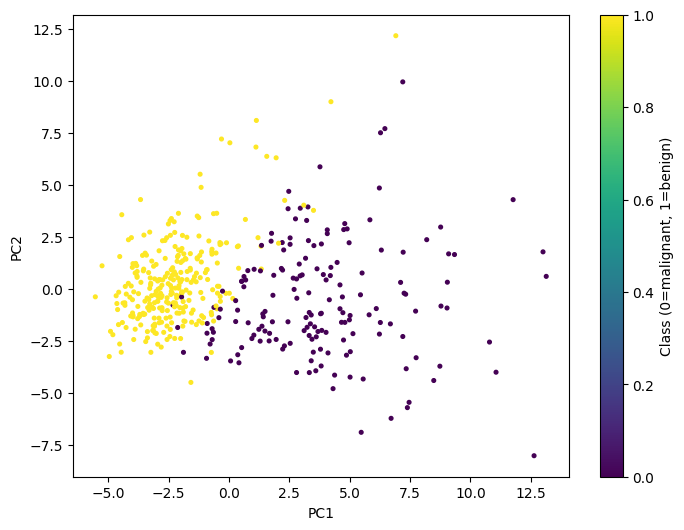

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s = 7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class (0=malignant, 1=benign)")
plt.show()

**Odpowiedź:** komponenty są wizualnie częściowo rozseparowane.

#### **Część 2**: SVM

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

#PCA i standaryzacja
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

pca_6 = PCA(n_components=6)
pca_2 = PCA(n_components=2)

X_train_pca6 = pca_6.fit_transform(X_train_std)
X_test_pca6  = pca_6.transform(X_test_std)

X_train_pca2 = pca_2.fit_transform(X_train_std)
X_test_pca2  = pca_2.transform(X_test_std)

#SVM
svm_full = SVC(kernel="rbf", C=2, gamma="scale")
svm_pca6 = SVC(kernel="rbf", C=2, gamma="scale")
svm_pca2 = SVC(kernel="rbf", C=2, gamma="scale")

svm_full.fit(X_train_std, y_train)
svm_pca6.fit(X_train_pca6, y_train)
svm_pca2.fit(X_train_pca2, y_train)

pred_full = svm_full.predict(X_test_std)
pred_pca6 = svm_pca6.predict(X_test_pca6)
pred_pca2 = svm_pca2.predict(X_test_pca2)

print("\n SVM na pełnych danych (30 cech)")
print("Accuracy:", accuracy_score(y_test, pred_full))
print(classification_report(y_test, pred_full))

print("\n SVM na PCA (6 komponentów)")
print("Accuracy:", accuracy_score(y_test, pred_pca6))
print(classification_report(y_test, pred_pca6))

print("\n SVM na PCA (2 komponenty)")
print("Accuracy:", accuracy_score(y_test, pred_pca2))
print(classification_report(y_test, pred_pca2))



 SVM na pełnych danych (30 cech)
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


 SVM na PCA (6 komponentów)
Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114


 SVM na PCA (2 komponenty)
Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    

#### **Komentarz:**
- PCA6 komponentów zachowuje prawie całą informację, ok. 90%, (accuracy: 95%)
- PCA2 traci sporo informacji, ale wciąż radzi sobie nieźle (accuracy: 93%)
- Pełne dane dają najlepszy wynik, bo SVM świetnie działa na wielu cechach po standaryzacji

#### **Część 3**: Regresja logistyczna

In [18]:
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

log_reg_full = LogisticRegression(max_iter=500)
log_reg_full.fit(X_train_std, y_train)

pred_full = log_reg_full.predict(X_test_std)
print("\n Logistic Regression (pełne dane)")
print("Accuracy:", accuracy_score(y_test, pred_full))
print(classification_report(y_test, pred_full))

pca6 = PCA(n_components=6)
X_train_pca6 = pca6.fit_transform(X_train_std)
X_test_pca6  = pca6.transform(X_test_std)

log_reg_6 = LogisticRegression(max_iter=500)
log_reg_6.fit(X_train_pca6, y_train)

pred_6 = log_reg_6.predict(X_test_pca6)
print("\n Logistic Regression (PCA = 6)")
print("Accuracy:", accuracy_score(y_test, pred_6))
print(classification_report(y_test, pred_6))

pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_std)
X_test_pca2  = pca2.transform(X_test_std)

log_reg_2 = LogisticRegression(max_iter=500)
log_reg_2.fit(X_train_pca2, y_train)

pred_2 = log_reg_2.predict(X_test_pca2)
print("\n Logistic Regression (PCA = 2)")
print("Accuracy:", accuracy_score(y_test, pred_2))
print(classification_report(y_test, pred_2))



 Logistic Regression (pełne dane)
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


 Logistic Regression (PCA = 6)
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


 Logistic Regression (PCA = 2)
Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        7

### **Komentarz**
- wszystkie PCA zapewniły dobre wyniki accuracy
- wyniki obliczeń PCA przeprowadzonych na pełnych danych oraz na 6 komponentach są bardzo zbliżone
- wyniki obliczeń PCA przeprowadzonych na 6 komponentach oraz na 2 komponentach są zbliżone
- większość istotnej informacji o nowotworze piersi jest zawarta w pierwszych kilku komponentach PCA
- zmienne są silnie skorelowane i mogą zawierać powtarzalną informację


#### Accuracy metod PCA dla różnej ilości komponent

| Metoda  | PCA pełne dane | PCA 6 komponent| PCA 2 komponenty |
|---------------------|----|-------|--------|
| **SVM** | **98%**   | **95%** | **93%** |
| **Regresja logistyczna** | **98%**   | **96%** | **95%** |

WNIOSEK: Redukcja wymiaru danych upraszcza obliczenia przy jednoczesnej minimalnej stracie dokładności wyników. Modele działają świetnie nawet po redukcji wymiaru. PCA pozwala na redukcję z 30 na 6 wymiarów bez istotnej utraty jakości.

<h4> Zadanie2: Rozważ jeszcze raz dane dotyczące twarzy różnych osób (fetch_lw_people) rozważane podczas ćwiczenia z SVM. Zastosuj PCA ze 150 komponentami. Jaki procent wariancji opisują te komponenty? Narsuj kilka początkowych komponent (wektory własne); oczywiście podobnie jak obrazy są to wektory $64\cdot47$ wymiarowe - przed narysowaniem należy jeszcze zastosować metodę reshape. Zastanów się nad ich interpretacją - zapisz swoją odpowiedź.

In [19]:
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_lfw_people


Wariancja dla 150 komponentów: 93.59%


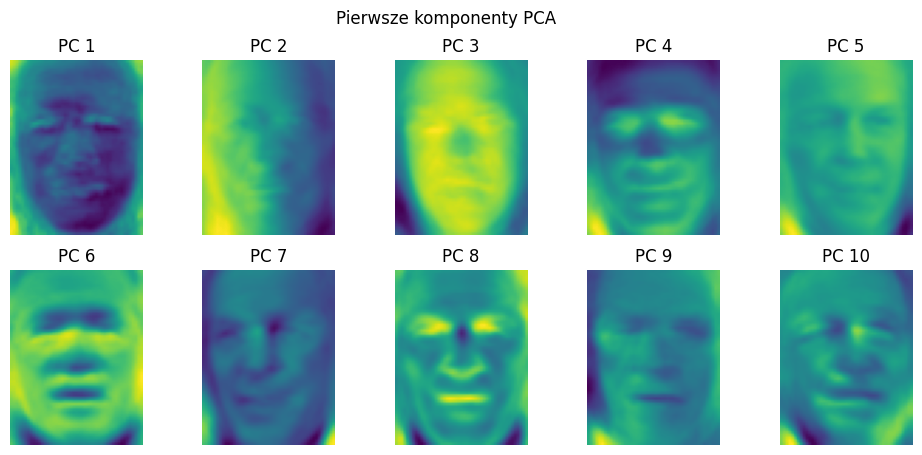

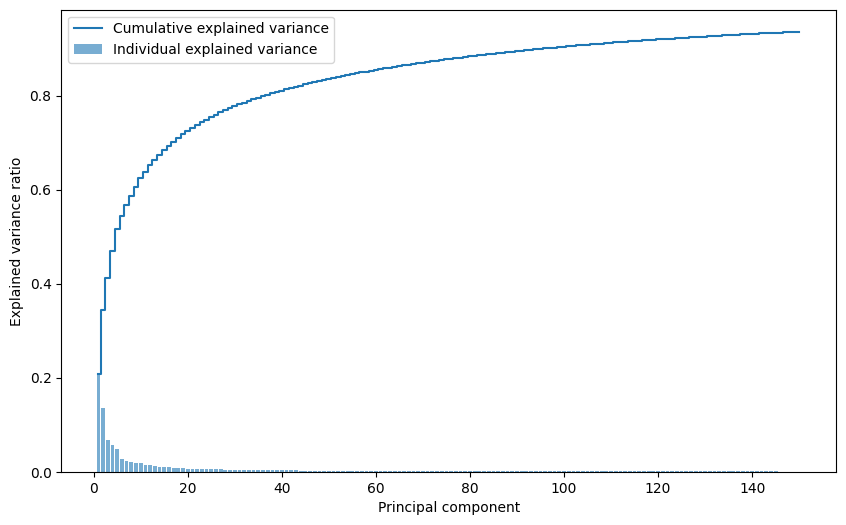

In [24]:
faces = fetch_lfw_people(min_faces_per_person=60)
X = faces.data               #shape: (n_samples, 64*47)
y = faces.target
h, w = faces.images.shape[1], faces.images.shape[2]

#PCA, 150 komponentów
pca = PCA(n_components=150, svd_solver="randomized", whiten=True)
X_pca = pca.fit_transform(X)

explained_var = pca.explained_variance_ratio_
cum_explained = explained_var.cumsum()

print(f"\nWariancja dla 150 komponentów: {cum_explained[-1]*100:.2f}%")

#wizualizacja kilku pierwszych komponentów
n_components_to_show = 10
eigenfaces = pca.components_.reshape((150, h, w))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i])
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.suptitle("Pierwsze komponenty PCA")
plt.show()

#PCA na 150 komponentach (dane do wykresu)
pca = PCA(n_components=150)
pca.fit(X)

var_exp = pca.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

plt.figure(figsize=(10,6))
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6,
        label='Individual explained variance')
plt.step(range(1, len(var_exp)+1), var_exp_cum, where='mid',
         label='Cumulative explained variance')

plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.legend(loc='best')
plt.show()

### **Komentarz**:
- 150 komponentów PCA opisuje 93% całkowitej wariancji (zamiast 3008 wymiarów (64×47), redukujemy do 150 przy minimalnej utracie informacji)
- niektóre z komponentów akcentują szczegółowe cechy: kształt głowy, twarz, tło, oczy, usta, brwi, linia włosów
- PCA wyłapuje najbardziej charakterystyczne elementy twarzy

<h4> Zadanie3: Rozważ dane: https://data.vision.ee.ethz.ch/cvl/ae_dataset/
    
- wybierz trzy przykładowe sygnały (np. violin_0.wav, violin_162.wav, rustle_177.wav)
 
- wygeneruj miksy tych sygnałów (zastosuj wybraną przez siebie macierz mieszającą)
    
- wyświetl: oryginalne sygnały, sygnały zmieszane oraz zrekonstruowane sygnały
    
    
Zwróć uwagę na amplitudy zrekonstruowanych sygnałów wyświetlonych na wykresie. Jeżeli są bardzo małe, należy przeskalować:
    
    
S1_reconstructed = S_reconstructed * (
 2 ** 15 - 1)/np.max(np.abs(S_reconstructed))

In [52]:
import wave
import wave
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import wave

def load_wav(path):
    sound = wave.open(path, 'r')
    raw = sound.readframes(-1)
    signal = np.frombuffer(raw, dtype=np.int16)  # <<< POPRAWNE
    sr = sound.getframerate()
    sound.close()
    return signal, sr


# --- wczytanie danych ---
s1, sr1 = load_wav("AudioEventDataset/train/violin/violin_3.wav")
s2, sr2 = load_wav("AudioEventDataset/train/violin/violin_162.wav")
s3, sr3 = load_wav("AudioEventDataset/train/rustle/rustle_177.wav")

print(len(s1), len(s2), len(s3))


41664 79067 192000


In [55]:
#wyrównanie długości sygnałów
L = min(len(s1), len(s2), len(s3))

s1 = s1[:L]
s2 = s2[:L]
s3 = s3[:L]

S = np.vstack([s1, s2, s3])  # shape (3, L)

#macierz miksowania sygnałów
A = np.array([
    [1.0, 0.5, 0.2],
    [0.3, 1.0, 0.4],
    [0.2, 0.3, 1.0]
])

X = A @ S  #sygnały zmiksowane

In [56]:
#odzyskiwanie sygnałów
ica = FastICA(n_components=3)
S_rec = ica.fit_transform(X.T).T   # ICA zwraca Lx3 → transponuję

#normalizacja
def normalize(sig):
    return (sig / np.max(np.abs(sig))) * (2**15 - 1)

s1_rec = normalize(S_rec[0]).astype(np.int16)
s2_rec = normalize(S_rec[1]).astype(np.int16)
s3_rec = normalize(S_rec[2]).astype(np.int16)


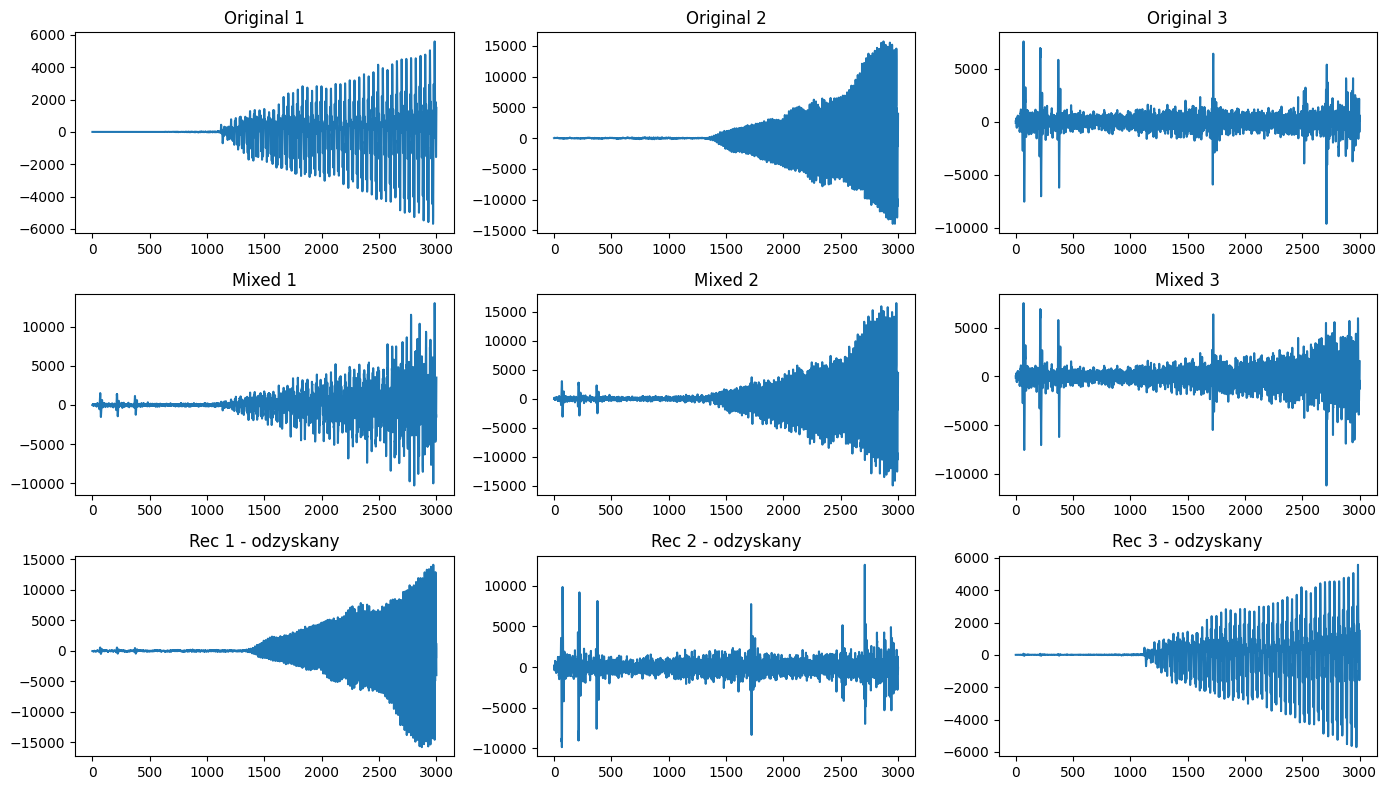

In [58]:
plt.figure(figsize=(14,8))

plt.subplot(3,3,1); plt.title("Original 1"); plt.plot(s1[:3000])
plt.subplot(3,3,2); plt.title("Original 2"); plt.plot(s2[:3000])
plt.subplot(3,3,3); plt.title("Original 3"); plt.plot(s3[:3000])

plt.subplot(3,3,4); plt.title("Mixed 1"); plt.plot(X[0,:3000])
plt.subplot(3,3,5); plt.title("Mixed 2"); plt.plot(X[1,:3000])
plt.subplot(3,3,6); plt.title("Mixed 3"); plt.plot(X[2,:3000])

plt.subplot(3,3,7); plt.title("Rec 1 - odzyskany"); plt.plot(s1_rec[:3000])
plt.subplot(3,3,8); plt.title("Rec 2 - odzyskany"); plt.plot(s2_rec[:3000])
plt.subplot(3,3,9); plt.title("Rec 3 - odzyskany"); plt.plot(s3_rec[:3000])

plt.tight_layout()
plt.show()


<h4> Zadanie4: Otwórz plik scrna.txt. Zawiera on dane dotyczące ekspresji wybranych genów w pewnej populacji komórek. Informację dotyczącą typu komórek/tkanki można znaleźć w pliku scrna_l.txt - kolumna Tissue_name.
    
- dokonaj transpozycji tabeli danych
- zastosuj transformację $f(x)=log(x+1)$
- wykonaj algorytm $PCA(k=2)$ i zwizualizuj wyniki, kolorując obserwacje wg grup
- wykonaj algorytm $PCA(k=30)$, a następnie $tSNE(2)$ i zwizualizuj wyniki, kolorując obserwacje wg grup
- skomentuj wyniki otrzymane w dwóch ostatnich podpunktach

In [102]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [65]:
#ekspresja genów
scrna = pd.read_csv("scrna.txt", sep=",", index_col=0)

#etykiety (tissues)
labels = pd.read_csv("scrna_l.txt", sep=",")

#transpozycja
scrna_T = scrna.T
print(scrna_T.shape)
scrna_T.head()


(300, 8686)


,MTND2P28,MTATP6P1,NOC2L,ISG15,CPSF3L,MXRA8,AURKAIP1,CCNL2,MRPL20,SSU72,...,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,MT-TP
Cell_2338_1,78,2053,1,2953,2,0,302,0,330,604,...,0,247,1,0,0,4,0,0,0,0
Cell_2338_10,559,1958,125,4938,42,0,132,235,477,869,...,919,8036,9953,220,1605,19428,5364,2016,20763,10
Cell_2338_11,811,4922,126,580,19,0,64,0,288,2046,...,2155,19647,13732,1052,2049,31773,4983,1191,20730,175
Cell_2338_12,705,4409,0,523,0,0,492,84,222,158,...,1981,18535,13928,960,1636,20163,6865,1531,20586,137
Cell_2338_13,384,2610,487,2609,37,0,11,13,44,530,...,850,10644,15764,167,1433,19893,6199,2009,16342,46


In [90]:
scrna_log = scrna_T.copy()
scrna_log[exp_cols] = np.log1p(scrna_log[exp_cols])

In [91]:
print(scrna_log.head())

              MTND2P28  MTATP6P1     NOC2L     ISG15    CPSF3L  MXRA8  \
Cell_names                                                              
Cell_2338_1   4.369448  7.627544  0.693147  7.990915  1.098612    0.0   
Cell_2338_10  6.327937  7.580189  4.836282  8.504918  3.761200    0.0   
Cell_2338_11  6.699500  8.501673  4.844187  6.364751  2.995732    0.0   
Cell_2338_12  6.559615  8.391630  0.000000  6.261492  0.000000    0.0   
Cell_2338_13  5.953243  7.867489  6.190315  7.867106  3.637586    0.0   

              AURKAIP1     CCNL2    MRPL20     SSU72  ...   MT-ATP8   MT-ATP6  \
Cell_names                                            ...                       
Cell_2338_1   5.713733  0.000000  5.802118  6.405228  ...  0.000000  5.513429   
Cell_2338_10  4.890349  5.463832  6.169611  6.768493  ...  6.824374  8.991811   
Cell_2338_11  4.174387  0.000000  5.666427  7.624131  ...  7.676010  9.885731   
Cell_2338_12  6.200509  4.442651  5.407172  5.068904  ...  7.591862  9.827470   
Ce

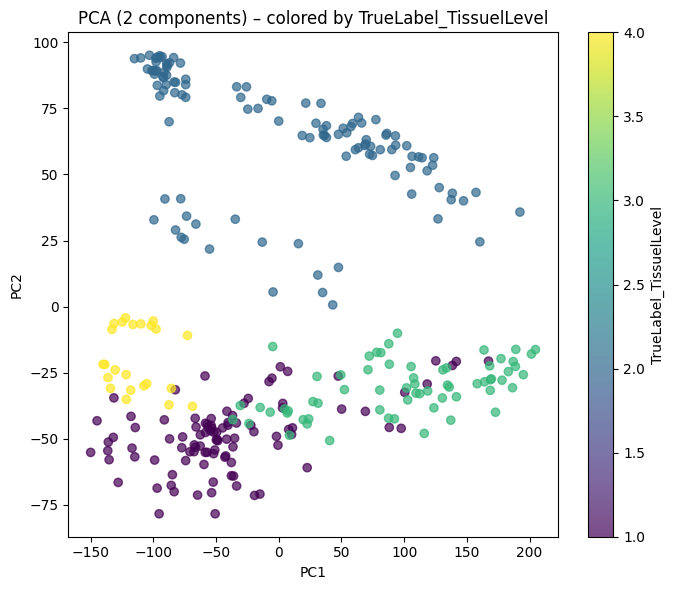

In [98]:
#zostawiamy tylko komórki obecne w macierzy ekspresji
labels = labels.loc[scrna_log.index]

#PCA2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scrna_log.values)

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=labels["TrueLabel_TissuelLevel"],
                      alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 components) – colored by TrueLabel_TissuelLevel")
plt.colorbar(scatter, label="TrueLabel_TissuelLevel")
plt.tight_layout()
plt.show()


DERMAL: 1 \
BLOOD: 2 \
NEURAL: 3 \
STEM: 4

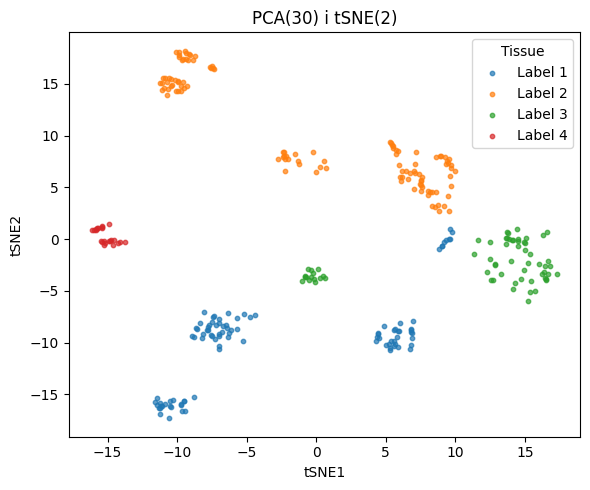

In [108]:
scrna_l = pd.read_csv("scrna_l.txt").set_index("Population")
scrna_l = scrna_l.loc[scrna_log.index]        #dopasowanie komórek
tissue = scrna_l["TrueLabel_TissuelLevel"]  #etykiety

pca30 = PCA(n_components=30)
X_pca30 = pca30.fit_transform(scrna_log.values)

#tSNE na PCA(30)
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_pca30)

plt.figure(figsize=(6,5))

for label in tissue.unique():
    mask = (tissue == label)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                s=10, alpha=0.7, label=f"Label {label}")
   
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.title("PCA(30) i tSNE(2)")
plt.legend(title="Tissue", loc="best")
plt.tight_layout()
plt.show()

### **Komentarz**:
Już po PCA(k=2) widzimy na wykresie rozróżnione niektóre z kategorii. Najbardziej oddalone od reszty kategorii są w populacji komóek krwi (2). Po przeprowadzeniu szerszego PCA(k=30) i TSNE widzimy wszystkie grupy całkowicie oddalone od siebie. \
**Wnioski**:
- profil ekspresji genów mocno różni się między tkankami
- komórki krwi (2) grupują się mocno, ponieważ komórki krwi mogą mieć specyficzne profile ekspresji
- najbardziej heterogeniczne są tkanki dermalne (wiele podgrup)
- komóki macierzyste - najbardziej podstawowy profil ekspresji
- tkanki neuronalne zwykle tworzą dwi grupy związane z różnymi etapami rozwoju lub typami neuronów
- metody nieliniowe (np. TSNE) dobrze radzą sobie z bardziej złożonymi zależnościami niż samo PCA.
